# 🎯 Motion Detection with GMM (Background Subtraction)
**Dataset**: CDnet2014  
**Method**: Gaussian Mixture Model (MOG2) — OpenCV  
**Task**: Phát hiện đối tượng chuyển động trong video

---
## Cấu trúc CDnet2014
```
CDnet2014/
  ├── baseline/
  │   ├── highway/
  │   │   ├── input/          ← frames gốc  (in000001.jpg)
  │   │   ├── groundtruth/    ← ground truth (gt000001.png)
  │   │   └── ROI.bmp         ← vùng quan tâm
  │   └── pedestrians/ ...
  ├── dynamicBackground/ ...
  └── cameraJitter/ ...
```

**Giá trị pixel trong groundtruth:**
| Giá trị | Ý nghĩa |
|---------|---------|
| `255` | Foreground (chuyển động thật) |
| `0`   | Background |
| `50`  | Hard shadow |
| `85`  | Outside ROI — **bỏ qua** |
| `170` | Unknown motion — **bỏ qua** |

---
## Metrics được đánh giá
| Metric | Công thức | Ghi chú |
|--------|-----------|---------|
| Precision | TP / (TP+FP) | Độ chính xác dự đoán FG |
| Recall (TPR) | TP / (TP+FN) | Độ nhạy với FG thật |
| F1-Score | 2·P·R / (P+R) | Cân bằng P và R |
| Specificity | TN / (TN+FP) | Độ chính xác nhận BG |
| FPR | FP / (FP+TN) | Tỷ lệ báo động nhầm |
| Accuracy | (TP+TN) / Total | Chính xác tổng thể |
| **PWC** | 100·(FN+FP)/Total | **Chuẩn CDnet2014** (càng nhỏ càng tốt) |
| **IoU** | TP / (TP+FP+FN) | Jaccard Index |
| **AUC-ROC** | Area under ROC | Khả năng phân loại tổng thể |

## 1. Cài đặt & Import

In [1]:
!pip install opencv-python-headless tqdm scikit-learn -q

import cv2
import numpy as np
import os
import glob
import json
from tqdm import tqdm
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

import pandas as pd
from sklearn.metrics import auc

print(f"OpenCV  : {cv2.__version__}")
print(f"NumPy   : {np.__version__}")
print(f"Pandas  : {pd.__version__}")
print("✅ Import thành công!")

OpenCV  : 4.13.0
NumPy   : 2.0.2
Pandas  : 2.3.3
✅ Import thành công!


## 2. Cấu hình

In [2]:
# =====================================================================
# DATASET
# =====================================================================
DATASET_ROOT = "/kaggle/input/datasets/maamri95/cdnet2014/dataset"

# None = chạy tất cả; hoặc chỉ định list, ví dụ: ["baseline", "dynamicBackground"]
SELECTED_CATEGORIES = None
SELECTED_VIDEOS     = None          # None = chạy tất cả video trong mỗi category

# =====================================================================
# GMM PARAMETERS (MOG2)
# =====================================================================
GMM_HISTORY       = 500    # Số frame lịch sử để học background model
GMM_VAR_THRESHOLD = 16     # Ngưỡng Mahalanobis² để phân loại foreground
GMM_DETECT_SHADOW = True   # Phát hiện shadow (gán pixel shadow = 127)

# =====================================================================
# POST-PROCESSING
# =====================================================================
WARMUP_FRAMES    = 200     # Frame khởi động — không dùng để tính metrics
BINARY_THRESHOLD = 200     # Pixel > ngưỡng → foreground (loại bỏ shadow=127)
MORPH_OPEN_SIZE  = 3       # Kernel opening (loại bỏ nhiễu nhỏ)
MORPH_CLOSE_SIZE = 7       # Kernel closing (lấp lỗ trong foreground blob)

# =====================================================================
# PR / ROC CURVE — Sweep threshold
# =====================================================================
# Thay đổi binary_threshold để vẽ đường cong PR & ROC
THRESHOLD_SWEEP = list(range(0, 256, 8))   # 0, 8, 16, ..., 248, 255

# =====================================================================
# OUTPUT
# =====================================================================
OUTPUT_DIR = "/kaggle/working/results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Dataset : {DATASET_ROOT}")
print(f"Output  : {OUTPUT_DIR}")
print(f"Thresholds sweep: {len(THRESHOLD_SWEEP)} values ({THRESHOLD_SWEEP[0]}→{THRESHOLD_SWEEP[-1]})")

Dataset : /kaggle/input/datasets/maamri95/cdnet2014/dataset
Output  : /kaggle/working/results
Thresholds sweep: 32 values (0→248)


## 3. Utility Functions

In [3]:
# =====================================================================
# 3.1  Lấy danh sách video trong dataset
# =====================================================================
def get_video_list(dataset_root, selected_categories=None, selected_videos=None):
    """Trả về list[dict]: {category, video_name, input_dir, gt_dir, roi_path}"""
    video_list   = []
    dataset_path = Path(dataset_root)

    for cat_path in sorted(dataset_path.iterdir()):
        if not cat_path.is_dir():
            continue
        category = cat_path.name
        if selected_categories and category not in selected_categories:
            continue
        for vid_path in sorted(cat_path.iterdir()):
            if not vid_path.is_dir():
                continue
            video_name = vid_path.name
            if selected_videos and video_name not in selected_videos:
                continue
            input_dir = vid_path / "input"
            gt_dir    = vid_path / "groundtruth"
            roi_path  = vid_path / "ROI.bmp"
            if input_dir.exists() and gt_dir.exists():
                video_list.append({
                    "category"   : category,
                    "video_name" : video_name,
                    "input_dir"  : str(input_dir),
                    "gt_dir"     : str(gt_dir),
                    "roi_path"   : str(roi_path) if roi_path.exists() else None,
                })
    return video_list


# =====================================================================
# 3.2  Đọc frames từ thư mục (sorted theo tên)
# =====================================================================
def get_sorted_frames(directory, extensions=("*.jpg", "*.png", "*.bmp")):
    frames = []
    for ext in extensions:
        frames.extend(glob.glob(os.path.join(directory, ext)))
    return sorted(frames)


# =====================================================================
# 3.3  Post-processing morphology
# =====================================================================
def postprocess_mask(mask, open_size=3, close_size=7):
    """Opening → loại nhiễu nhỏ; Closing → lấp lỗ trong blob."""
    k_open  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (open_size,  open_size))
    k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close_size, close_size))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  k_open)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k_close)
    return mask


# =====================================================================
# 3.4  Tính toán TP/FP/FN/TN từ predicted mask vs CDnet GT
# =====================================================================
def get_valid_pixels(pred_mask, gt_mask, roi_mask=None):
    """
    Trả về (pred_binary_flat, gt_binary_flat) đã lọc valid pixels.
    
    CDnet2014 groundtruth:
      255 → Foreground thật
      0   → Background rõ ràng
      50  → Hard shadow (tùy chọn xử lý như BG)
      85  → Outside ROI       ← BỎ QUA
      170 → Unknown / ambiguous ← BỎ QUA
    """
    # Vùng pixel đáng tin: loại bỏ outside-ROI (85) và unknown (170)
    valid = ((gt_mask != 85) & (gt_mask != 170)).astype(np.uint8)
    if roi_mask is not None:
        roi_b = (roi_mask > 0).astype(np.uint8)
        valid = valid & roi_b

    gt_fg   = (gt_mask == 255).astype(np.uint8)
    pred_b  = (pred_mask > 0).astype(np.uint8)

    pred_v = pred_b[valid == 1].astype(bool)
    gt_v   = gt_fg[valid == 1].astype(bool)
    return pred_v, gt_v


def confusion_values(pred_v, gt_v):
    TP = int(np.sum( pred_v &  gt_v))
    FP = int(np.sum( pred_v & ~gt_v))
    FN = int(np.sum(~pred_v &  gt_v))
    TN = int(np.sum(~pred_v & ~gt_v))
    return TP, FP, FN, TN


def metrics_from_confusion(TP, FP, FN, TN):
    eps = 1e-8
    precision   = TP / (TP + FP + eps)
    recall      = TP / (TP + FN + eps)
    f1          = 2 * precision * recall / (precision + recall + eps)
    specificity = TN / (TN + FP + eps)
    fpr         = FP / (FP + TN + eps)
    accuracy    = (TP + TN) / (TP + FP + FN + TN + eps)
    pwc         = 100 * (FN + FP) / (TP + FP + FN + TN + eps)   # CDnet2014 official
    iou         = TP / (TP + FP + FN + eps)                       # Jaccard
    return {
        "Precision"   : round(precision,   4),
        "Recall"      : round(recall,       4),
        "F1"          : round(f1,           4),
        "Specificity" : round(specificity,  4),
        "FPR"         : round(fpr,          4),
        "Accuracy"    : round(accuracy,     4),
        "PWC"         : round(pwc,          4),
        "IoU"         : round(iou,          4),
    }


print("✅ Utility functions sẵn sàng!")

✅ Utility functions sẵn sàng!


## 4. GMM Processing — Chạy từng Video

In [4]:
def process_video(video_info, config):
    """
    Chạy GMM (MOG2) trên toàn bộ frame của một video.
    
    Trả về dict chứa:
      - metrics tổng hợp (Precision, Recall, F1, Specificity, FPR,
                          Accuracy, PWC, IoU, AUC-ROC, AUC-PR)
      - TP/FP/FN/TN aggregate (để vẽ confusion matrix)
      - sweep data (để vẽ PR curve & ROC curve)
    """
    category   = video_info["category"]
    video_name = video_info["video_name"]
    input_dir  = video_info["input_dir"]
    gt_dir     = video_info["gt_dir"]
    roi_path   = video_info["roi_path"]

    input_frames = get_sorted_frames(input_dir)
    gt_frames    = get_sorted_frames(gt_dir)

    if not input_frames:
        print(f"  ⚠️  Không có frame trong {input_dir}")
        return None

    # Đọc ROI
    roi_mask = None
    if roi_path:
        roi_mask = cv2.imread(roi_path, cv2.IMREAD_GRAYSCALE)

    # Build gt_dict: số frame → đường dẫn gt
    gt_dict = {}
    for gp in gt_frames:
        num = "".join(filter(str.isdigit, os.path.basename(gp)))
        gt_dict[num] = gp

    # Tạo GMM subtractor
    subtractor = cv2.createBackgroundSubtractorMOG2(
        history       = config["gmm_history"],
        varThreshold  = config["gmm_var_threshold"],
        detectShadows = config["gmm_detect_shadow"],
    )

    # Thư mục lưu predicted masks
    pred_dir = os.path.join(config["output_dir"], category, video_name, "pred_masks")
    os.makedirs(pred_dir, exist_ok=True)

    warmup  = config["warmup_frames"]
    bin_thr = config["binary_threshold"]

    # ──────────────────────────────────────────────────
    # Buffer: lưu raw fg_mask (0-255) + gt_binary mỗi frame
    # để sau đó sweep threshold → PR/ROC curve
    # ──────────────────────────────────────────────────
    raw_fg_list = []   # raw MOG2 output (trước threshold)
    gt_bin_list = []   # ground truth binary (valid pixels)

    # Aggregate TP/FP/FN/TN (tại threshold chính)
    agg_TP = agg_FP = agg_FN = agg_TN = 0

    for frame_idx, in_path in enumerate(tqdm(
        input_frames, desc=f"  {category}/{video_name}", leave=False
    )):
        frame = cv2.imread(in_path)
        if frame is None:
            continue

        # Áp dụng GMM → raw mask (0=BG, 127=shadow, 255=FG)
        fg_raw = subtractor.apply(frame)

        # Nhị phân hoá tại threshold chính
        _, fg_binary = cv2.threshold(fg_raw, bin_thr, 255, cv2.THRESH_BINARY)
        fg_clean = postprocess_mask(fg_binary,
                                    config["morph_open_size"],
                                    config["morph_close_size"])

        # Lưu predicted mask
        num = "".join(filter(str.isdigit, os.path.basename(in_path)))
        cv2.imwrite(os.path.join(pred_dir, f"bin{num}.png"), fg_clean)

        # Bỏ warm-up
        if frame_idx < warmup:
            continue

        if num not in gt_dict:
            continue

        gt_img = cv2.imread(gt_dict[num], cv2.IMREAD_GRAYSCALE)
        if gt_img is None:
            continue

        roi_r = None
        if roi_mask is not None:
            roi_r = cv2.resize(roi_mask, (gt_img.shape[1], gt_img.shape[0]),
                               interpolation=cv2.INTER_NEAREST)

        # Aggregate TP/FP/FN/TN
        pred_v, gt_v = get_valid_pixels(fg_clean, gt_img, roi_r)
        tp, fp, fn, tn = confusion_values(pred_v, gt_v)
        agg_TP += tp; agg_FP += fp; agg_FN += fn; agg_TN += tn

        # Lưu raw score (prob FG ≈ fg_raw value) cho PR/ROC sweep
        # Chỉ lưu valid pixels
        valid = ((gt_img != 85) & (gt_img != 170))
        if roi_r is not None:
            valid = valid & (roi_r > 0)

        raw_fg_list.append(fg_raw[valid].astype(np.float32) / 255.0)
        gt_bin_list.append((gt_img[valid] == 255).astype(np.uint8))

    if agg_TP + agg_FP + agg_FN + agg_TN == 0:
        return None

    # ──────────────────────────────────────────────────
    # Metrics tại threshold chính
    # ──────────────────────────────────────────────────
    m = metrics_from_confusion(agg_TP, agg_FP, agg_FN, agg_TN)

    # ──────────────────────────────────────────────────
    # Sweep threshold → PR curve & ROC curve
    # ──────────────────────────────────────────────────
    if raw_fg_list:
        all_scores = np.concatenate(raw_fg_list)
        all_labels = np.concatenate(gt_bin_list).astype(bool)

        precisions, recalls, fprs = [], [], []
        for thr in config["threshold_sweep"]:
            thr_norm = thr / 255.0
            pred_thr = (all_scores >= thr_norm)
            tp_s = int(np.sum( pred_thr &  all_labels))
            fp_s = int(np.sum( pred_thr & ~all_labels))
            fn_s = int(np.sum(~pred_thr &  all_labels))
            tn_s = int(np.sum(~pred_thr & ~all_labels))
            eps  = 1e-8
            precisions.append(tp_s / (tp_s + fp_s + eps))
            recalls.append(   tp_s / (tp_s + fn_s + eps))
            fprs.append(      fp_s / (fp_s + tn_s + eps))

        # Sắp xếp theo recall tăng dần để tính AUC
        pr_pairs  = sorted(zip(recalls, precisions))
        roc_pairs = sorted(zip(fprs,    recalls))

        roc_fpr_s, roc_tpr_s = zip(*roc_pairs)
        pr_rec_s,  pr_pre_s  = zip(*pr_pairs)

        auc_roc = float(auc(list(roc_fpr_s), list(roc_tpr_s)))
        auc_pr  = float(auc(list(pr_rec_s),  list(pr_pre_s)))

        sweep_data = {
            "pr_recalls"    : list(pr_rec_s),
            "pr_precisions" : list(pr_pre_s),
            "roc_fprs"      : list(roc_fpr_s),
            "roc_tprs"      : list(roc_tpr_s),
        }
    else:
        auc_roc, auc_pr, sweep_data = 0.0, 0.0, {}

    return {
        "category"   : category,
        "video_name" : video_name,
        "n_frames"   : agg_TP + agg_FP + agg_FN + agg_TN,
        "TP"         : agg_TP,
        "FP"         : agg_FP,
        "FN"         : agg_FN,
        "TN"         : agg_TN,
        **m,
        "AUC_ROC"    : round(auc_roc, 4),
        "AUC_PR"     : round(auc_pr,  4),
        "sweep"      : sweep_data,
    }

print("✅ process_video() sẵn sàng!")

✅ process_video() sẵn sàng!


## 5. Chạy Toàn Bộ Dataset

In [5]:
config = {
    "gmm_history"       : GMM_HISTORY,
    "gmm_var_threshold" : GMM_VAR_THRESHOLD,
    "gmm_detect_shadow" : GMM_DETECT_SHADOW,
    "warmup_frames"     : WARMUP_FRAMES,
    "binary_threshold"  : BINARY_THRESHOLD,
    "morph_open_size"   : MORPH_OPEN_SIZE,
    "morph_close_size"  : MORPH_CLOSE_SIZE,
    "threshold_sweep"   : THRESHOLD_SWEEP,
    "output_dir"        : OUTPUT_DIR,
}

video_list = get_video_list(DATASET_ROOT,
                            selected_categories=SELECTED_CATEGORIES,
                            selected_videos=SELECTED_VIDEOS)

print(f"Tìm thấy {len(video_list)} video:")
for v in video_list:
    print(f"  [{v['category']:25s}] {v['video_name']}")

Tìm thấy 53 video:
  [PTZ                      ] continuousPan
  [PTZ                      ] intermittentPan
  [PTZ                      ] twoPositionPTZCam
  [PTZ                      ] zoomInZoomOut
  [badWeather               ] blizzard
  [badWeather               ] skating
  [badWeather               ] snowFall
  [badWeather               ] wetSnow
  [baseline                 ] PETS2006
  [baseline                 ] highway
  [baseline                 ] office
  [baseline                 ] pedestrians
  [cameraJitter             ] badminton
  [cameraJitter             ] boulevard
  [cameraJitter             ] sidewalk
  [cameraJitter             ] traffic
  [dynamicBackground        ] boats
  [dynamicBackground        ] canoe
  [dynamicBackground        ] fall
  [dynamicBackground        ] fountain01
  [dynamicBackground        ] fountain02
  [dynamicBackground        ] overpass
  [intermittentObjectMotion ] abandonedBox
  [intermittentObjectMotion ] parking
  [intermittentObjectMo

In [6]:
all_results = []

for video_info in video_list:
    print(f"\n▶ [{video_info['category']}] {video_info['video_name']}")
    result = process_video(video_info, config)
    if result:
        all_results.append(result)
        print(f"   F1={result['F1']:.4f} | Prec={result['Precision']:.4f} | "
              f"Rec={result['Recall']:.4f} | IoU={result['IoU']:.4f} | "
              f"PWC={result['PWC']:.2f}% | AUC-ROC={result['AUC_ROC']:.4f}")

print(f"\n✅ Hoàn tất! Đã xử lý {len(all_results)} video.")


▶ [PTZ] continuousPan


   F1=0.0518 | Prec=0.0276 | Rec=0.4135 | IoU=0.0266 | PWC=9.50% | AUC-ROC=0.7250

▶ [PTZ] intermittentPan


   F1=0.0873 | Prec=0.0544 | Rec=0.2205 | IoU=0.0456 | PWC=6.51% | AUC-ROC=0.7103

▶ [PTZ] twoPositionPTZCam


   F1=0.7143 | Prec=0.8747 | Rec=0.6036 | IoU=0.5556 | PWC=0.73% | AUC-ROC=0.8918

▶ [PTZ] zoomInZoomOut


   F1=0.0496 | Prec=0.0255 | Rec=0.8614 | IoU=0.0254 | PWC=6.96% | AUC-ROC=0.8609

▶ [badWeather] blizzard


...

   F1=0.7402 | Prec=0.9740 | Rec=0.5969 | IoU=0.5875 | PWC=0.85% | AUC-ROC=0.8643

▶ [turbulence] turbulence0


   F1=0.1410 | Prec=0.0785 | Rec=0.6919 | IoU=0.0758 | PWC=1.59% | AUC-ROC=0.9038

▶ [turbulence] turbulence1


   F1=0.2792 | Prec=0.1902 | Rec=0.5246 | IoU=0.1622 | PWC=1.03% | AUC-ROC=0.8686

▶ [turbulence] turbulence2


   F1=0.5608 | Prec=0.4563 | Rec=0.7276 | IoU=0.3897 | PWC=0.04% | AUC-ROC=0.9372

▶ [turbulence] turbulence3


   F1=0.7432 | Prec=0.7461 | Rec=0.7403 | IoU=0.5914 | PWC=0.82% | AUC-ROC=0.8879

✅ Hoàn tất! Đã xử lý 53 video.


## 6. Tổng Hợp Kết Quả

In [7]:
METRIC_COLS = ["Precision", "Recall", "F1", "Specificity",
               "FPR", "Accuracy", "PWC", "IoU", "AUC_ROC", "AUC_PR"]

df = pd.DataFrame(all_results)

# ── Tính aggregate TP/FP/FN/TN cho toàn dataset
total_TP = df["TP"].sum()
total_FP = df["FP"].sum()
total_FN = df["FN"].sum()
total_TN = df["TN"].sum()

# ── Overall metrics (từ aggregate confusion, không phải average-of-averages)
overall_m = metrics_from_confusion(total_TP, total_FP, total_FN, total_TN)

# ── AUC lấy mean theo video (AUC không thể cộng dồn)
overall_m["AUC_ROC"] = round(df["AUC_ROC"].mean(), 4)
overall_m["AUC_PR"]  = round(df["AUC_PR"].mean(),  4)

# ── Per-category
df_cat = df.groupby("category")[METRIC_COLS].mean().round(4)

print("=" * 80)
print("KẾT QUẢ TỪNG VIDEO")
print("=" * 80)
display_cols = ["category", "video_name", "n_frames"] + METRIC_COLS
print(df[display_cols].to_string(index=False))

print("\n" + "=" * 80)
print("TRUNG BÌNH THEO CATEGORY")
print("=" * 80)
print(df_cat.to_string())

print("\n" + "=" * 80)
print("OVERALL (aggregate pixel-level)")
print("=" * 80)
for k, v in overall_m.items():
    print(f"  {k:<12}: {v:.4f}")

# ── Lưu file
df.drop(columns=["sweep"]).to_csv(os.path.join(OUTPUT_DIR, "results_per_video.csv"), index=False)
df_cat.to_csv(os.path.join(OUTPUT_DIR, "results_per_category.csv"))

overall_export = {**overall_m, "TP": int(total_TP), "FP": int(total_FP),
                  "FN": int(total_FN), "TN": int(total_TN), "config": config}
with open(os.path.join(OUTPUT_DIR, "overall_results.json"), "w") as f:
    json.dump(overall_export, f, indent=2, default=str)

print(f"\n💾 Đã lưu CSV & JSON vào {OUTPUT_DIR}")

KẾT QUẢ TỪNG VIDEO
                category          video_name   n_frames  Precision  Recall     F1  Specificity    FPR  Accuracy     PWC    IoU  AUC_ROC  AUC_PR
                     PTZ       continuousPan  185631737     0.0276  0.4135 0.0518       0.9081 0.0919    0.9050  9.4961 0.0266   0.7250  0.0110
                     PTZ     intermittentPan  214160198     0.0544  0.2205 0.0873       0.9451 0.0549    0.9349  6.5141 0.0456   0.7103  0.0333
                     PTZ   twoPositionPTZCam   71746004     0.8747  0.6036 0.7143       0.9987 0.0013    0.9927  0.7328 0.5556   0.8918  0.1756
                     PTZ       zoomInZoomOut   24078695     0.0255  0.8614 0.0496       0.9306 0.0694    0.9304  6.9593 0.0254   0.8609  0.0019
              badWeather            blizzard 1051194744     0.7443  0.0573 0.1064       0.9998 0.0002    0.9888  1.1221 0.0562   0.8805  0.5834
              badWeather             skating  298552083     0.8662  0.7704 0.8155       0.9938 0.0062    0.9827  1.72

## 7. Confusion Matrix
Pixel-level confusion matrix (aggregate toàn dataset).  
Mỗi pixel trong vùng valid được xem là một mẫu với nhãn **Foreground / Background**.

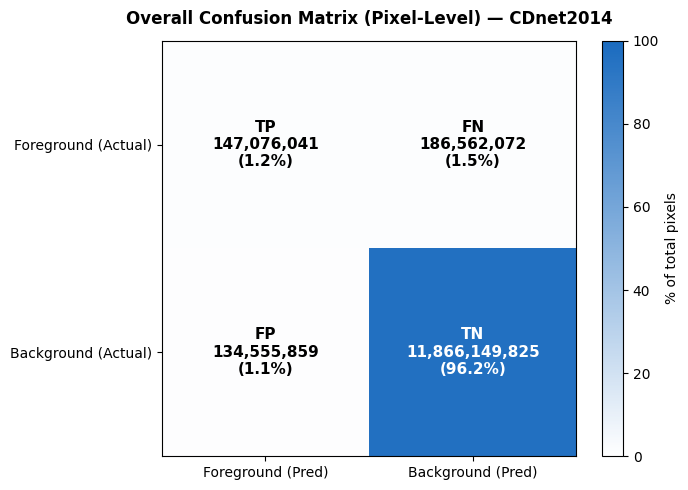

💾 Saved: confusion_matrix_overall.png


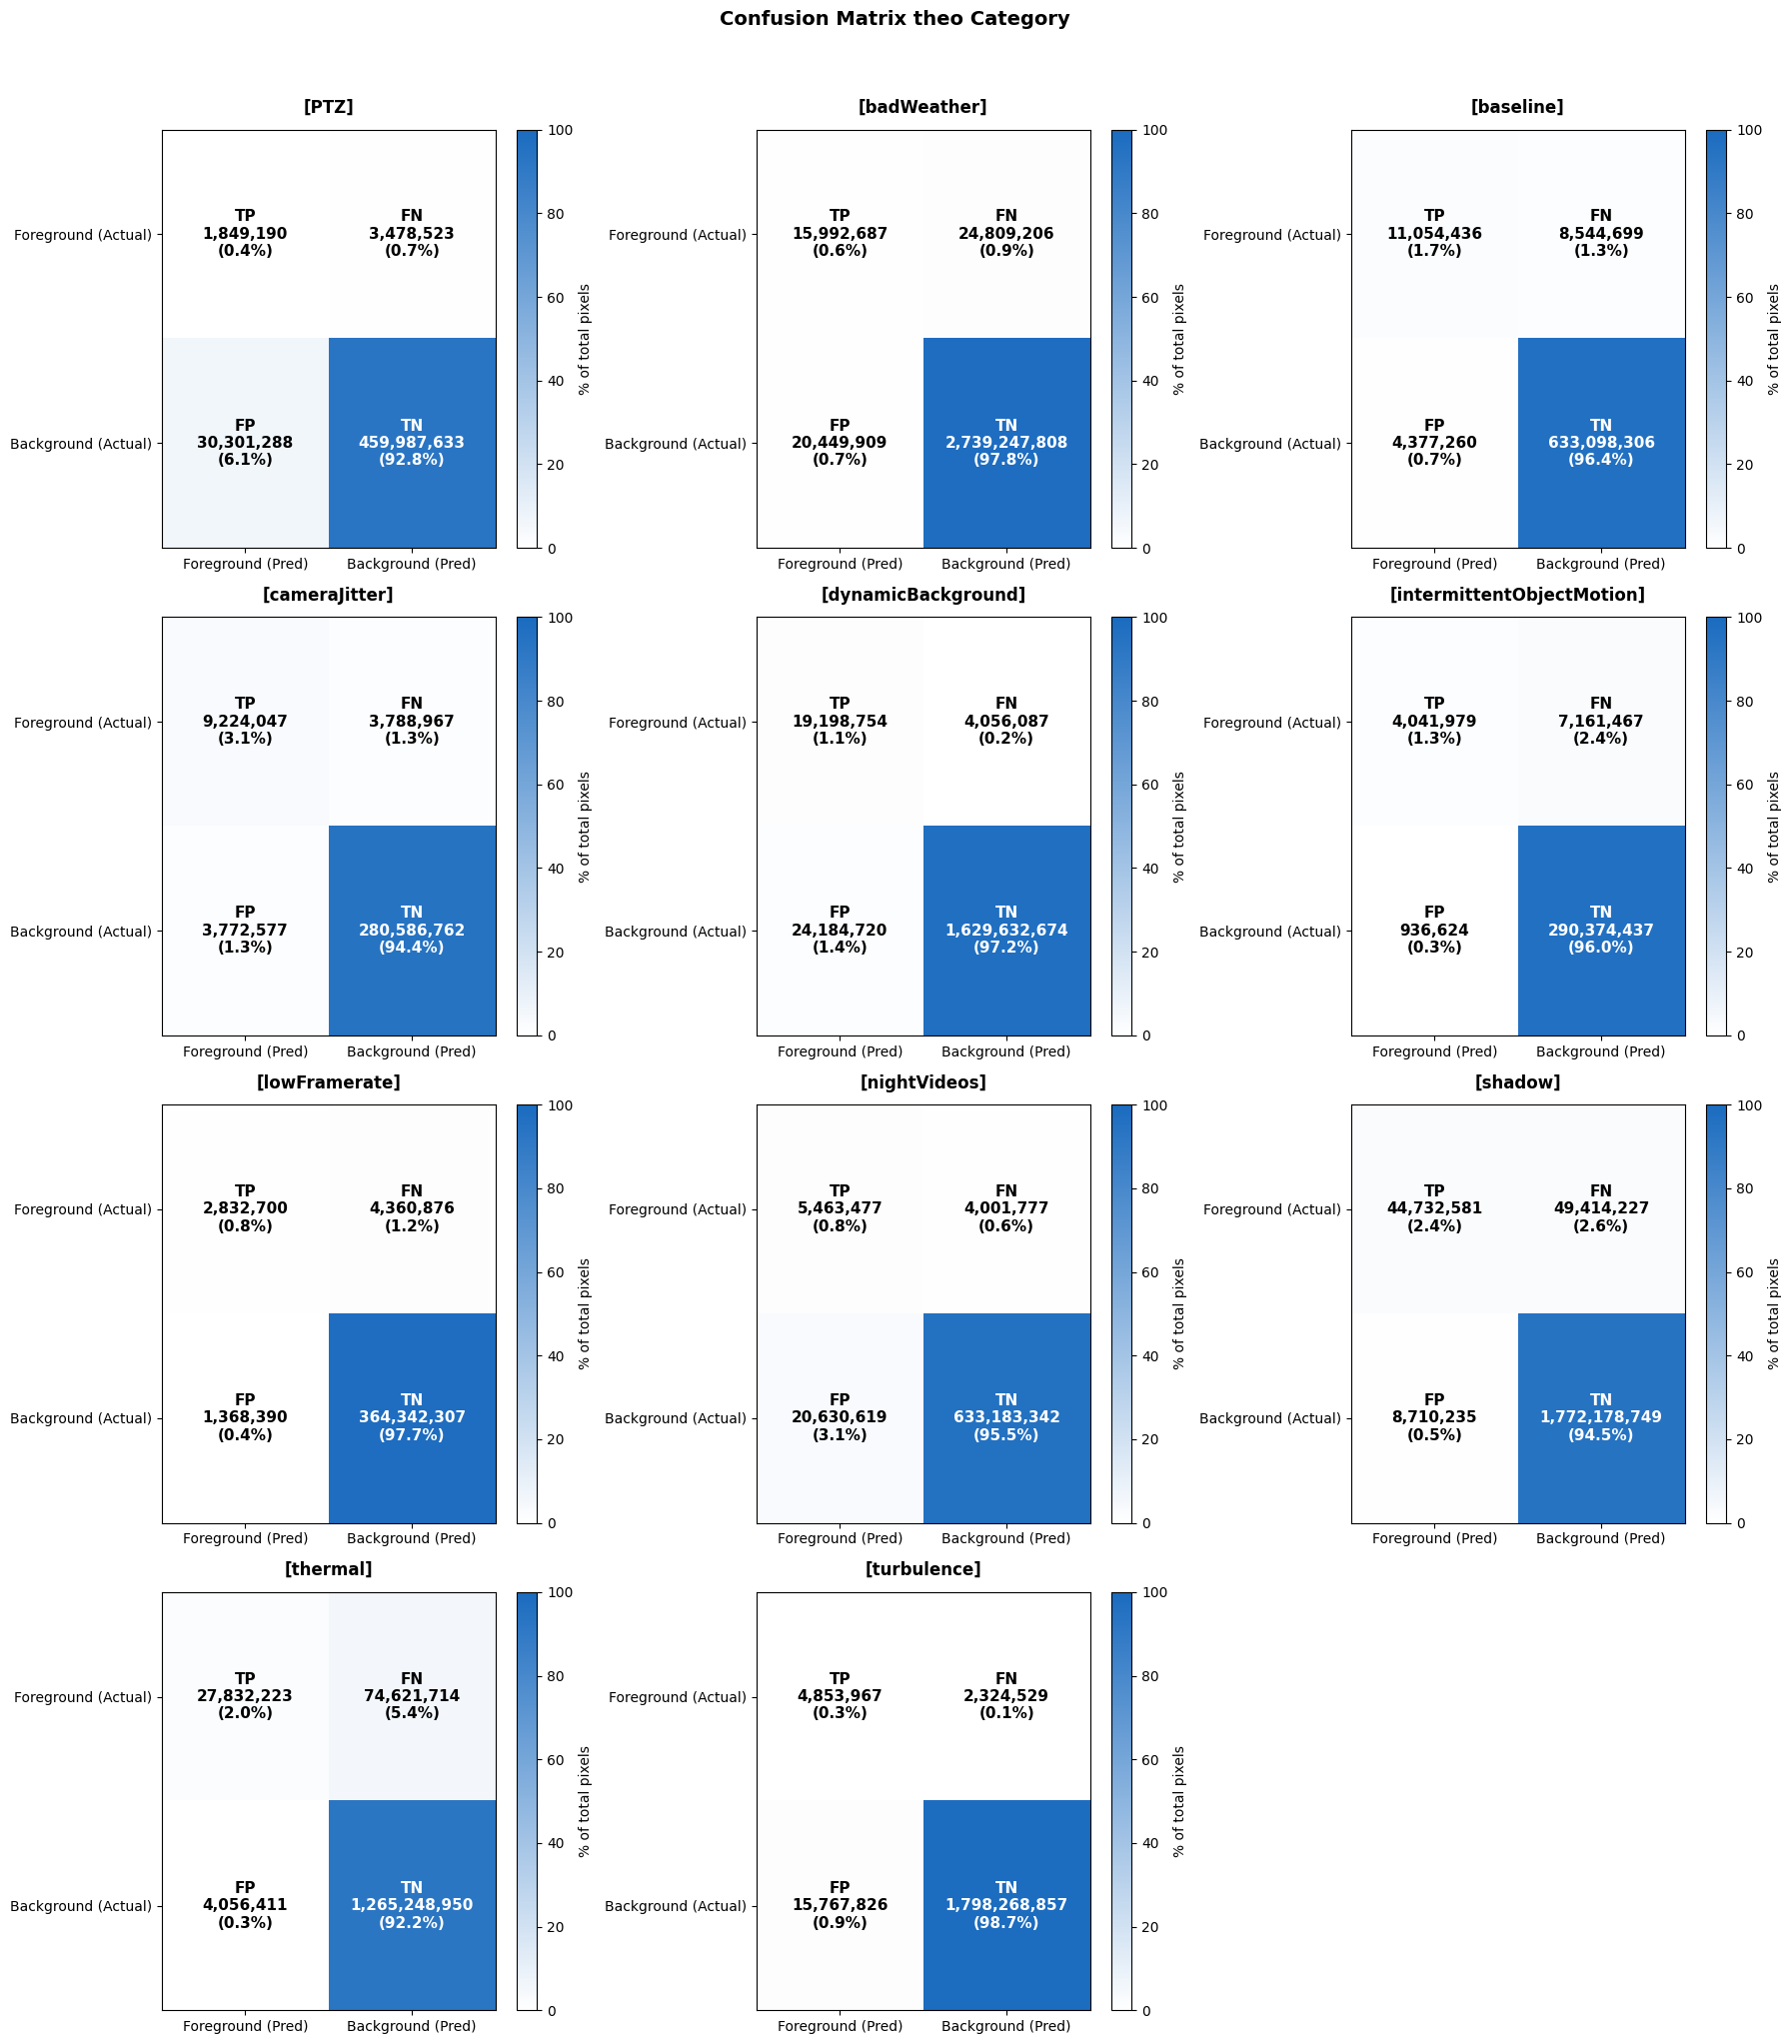

💾 Saved: confusion_matrix_per_category.png


In [8]:
def plot_confusion_matrix(TP, FP, FN, TN, title="Confusion Matrix", ax=None, save_path=None):
    """Vẽ confusion matrix dạng heatmap với chú thích đầy đủ."""
    cm = np.array([[TP, FN],
                   [FP, TN]], dtype=np.int64)

    total  = TP + FP + FN + TN
    cm_pct = cm / (total + 1e-8) * 100          # tỷ lệ phần trăm

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    cmap = LinearSegmentedColormap.from_list("cm_cmap", ["#ffffff", "#1a6bbf"])
    im = ax.imshow(cm_pct, cmap=cmap, vmin=0, vmax=100, aspect="auto")

    labels = [["TP", "FN"],
              ["FP", "TN"]]
    pred_labels = ["Foreground (Pred)", "Background (Pred)"]
    true_labels = ["Foreground (Actual)", "Background (Actual)"]

    ax.set_xticks([0, 1]); ax.set_xticklabels(pred_labels, fontsize=10)
    ax.set_yticks([0, 1]); ax.set_yticklabels(true_labels, fontsize=10)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=12)

    for i in range(2):
        for j in range(2):
            count = cm[i, j]
            pct   = cm_pct[i, j]
            text_color = "white" if pct > 50 else "black"
            ax.text(j, i,
                    f"{labels[i][j]}\n{count:,}\n({pct:.1f}%)",
                    ha="center", va="center",
                    fontsize=11, fontweight="bold", color=text_color)

    plt.colorbar(im, ax=ax, label="% of total pixels")
    return ax


# ── 1. Overall confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))
plot_confusion_matrix(total_TP, total_FP, total_FN, total_TN,
                      title="Overall Confusion Matrix (Pixel-Level) — CDnet2014", ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_overall.png"), dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved: confusion_matrix_overall.png")

# ── 2. Per-category confusion matrix (subplot grid)
if len(df_cat) >= 1:
    n_cats = len(df_cat)
    ncols  = min(3, n_cats)
    nrows  = (n_cats + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(6 * ncols, 5 * nrows))
    axes_flat = np.array(axes).flatten() if n_cats > 1 else [axes]

    for idx, cat in enumerate(df_cat.index):
        cat_df = df[df["category"] == cat]
        cTP = cat_df["TP"].sum(); cFP = cat_df["FP"].sum()
        cFN = cat_df["FN"].sum(); cTN = cat_df["TN"].sum()
        plot_confusion_matrix(cTP, cFP, cFN, cTN,
                              title=f"[{cat}]", ax=axes_flat[idx])

    # Ẩn subplot thừa
    for idx in range(n_cats, len(axes_flat)):
        axes_flat[idx].set_visible(False)

    fig.suptitle("Confusion Matrix theo Category", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_per_category.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Saved: confusion_matrix_per_category.png")

## 8. PR Curve & ROC Curve
Bằng cách thay đổi `binary_threshold` từ 0 → 255, ta thu được đường cong  
**Precision-Recall** và **ROC (TPR vs FPR)** cho từng video, sau đó vẽ trung bình.

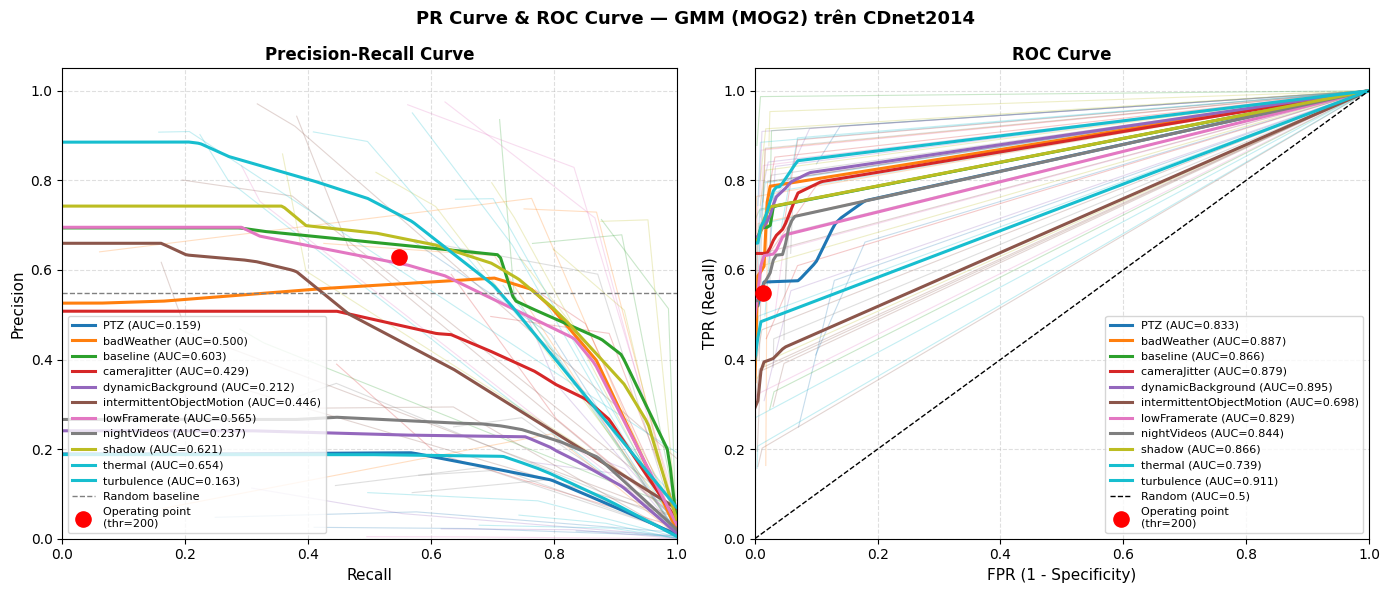

💾 Saved: pr_roc_curves.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("PR Curve & ROC Curve — GMM (MOG2) trên CDnet2014",
             fontsize=13, fontweight="bold")

ax_pr, ax_roc = axes

# Màu theo category
cats       = df["category"].unique().tolist()
cat_colors = {c: plt.cm.tab10(i / max(len(cats)-1, 1)) for i, c in enumerate(cats)}

# Thu thập global sweep để tính mean curve
all_pr_by_cat  = {c: {"recalls": [], "precs": []} for c in cats}
all_roc_by_cat = {c: {"fprs":    [], "tprs":  []} for c in cats}

for res in all_results:
    sweep = res.get("sweep", {})
    if not sweep:
        continue
    cat = res["category"]
    vname = res["video_name"]
    color = cat_colors[cat]

    pr_rec = sweep["pr_recalls"]
    pr_pre = sweep["pr_precisions"]
    rc_fpr = sweep["roc_fprs"]
    rc_tpr = sweep["roc_tprs"]

    # Vẽ từng video (mờ)
    ax_pr.plot(pr_rec, pr_pre, color=color, alpha=0.25, linewidth=0.8)
    ax_roc.plot(rc_fpr, rc_tpr, color=color, alpha=0.25, linewidth=0.8)

    all_pr_by_cat[cat]["recalls"].append(pr_rec)
    all_pr_by_cat[cat]["precs"].append(pr_pre)
    all_roc_by_cat[cat]["fprs"].append(rc_fpr)
    all_roc_by_cat[cat]["tprs"].append(rc_tpr)


# Vẽ mean curve theo category (đậm)
def interp_mean(xs_list, ys_list, n=200):
    """Nội suy tất cả curve lên cùng grid x rồi lấy mean."""
    x_grid = np.linspace(0, 1, n)
    ys_interp = [np.interp(x_grid, xs, ys) for xs, ys in zip(xs_list, ys_list)]
    return x_grid, np.mean(ys_interp, axis=0)

legend_handles = []
for cat in cats:
    color = cat_colors[cat]
    # PR
    recs  = all_pr_by_cat[cat]["recalls"]
    precs = all_pr_by_cat[cat]["precs"]
    if recs:
        x_g, y_g = interp_mean(recs, precs)
        auc_val   = auc(x_g, np.clip(y_g, 0, 1))
        h, = ax_pr.plot(x_g, y_g, color=color, linewidth=2.2,
                        label=f"{cat} (AUC={auc_val:.3f})")
        legend_handles.append(h)
    # ROC
    fprs = all_roc_by_cat[cat]["fprs"]
    tprs = all_roc_by_cat[cat]["tprs"]
    if fprs:
        x_g, y_g = interp_mean(fprs, tprs)
        auc_val   = auc(x_g, np.clip(y_g, 0, 1))
        ax_roc.plot(x_g, y_g, color=color, linewidth=2.2,
                    label=f"{cat} (AUC={auc_val:.3f})")

# Vẽ đường baseline
ax_pr.axhline(y=df["Recall"].mean(), color="gray", linestyle="--",
              linewidth=1, label="Random baseline")
ax_roc.plot([0,1], [0,1], "k--", linewidth=1, label="Random (AUC=0.5)")

# Đánh dấu điểm hoạt động (threshold chính)
op_x_pr  = df["Recall"].mean()
op_y_pr  = df["Precision"].mean()
op_x_roc = df["FPR"].mean()
op_y_roc = df["Recall"].mean()
ax_pr.scatter([op_x_pr],  [op_y_pr],  s=120, zorder=5, color="red",
              label=f"Operating point\n(thr={BINARY_THRESHOLD})")
ax_roc.scatter([op_x_roc], [op_y_roc], s=120, zorder=5, color="red",
               label=f"Operating point\n(thr={BINARY_THRESHOLD})")

# Format
for ax, xlabel, ylabel, title in [
    (ax_pr,  "Recall",      "Precision", "Precision-Recall Curve"),
    (ax_roc, "FPR (1 - Specificity)", "TPR (Recall)", "ROC Curve"),
]:
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(fontsize=8, loc="lower left" if ax == ax_pr else "lower right")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "pr_roc_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved: pr_roc_curves.png")

## 9. Bar Charts — Metrics theo Video & Category

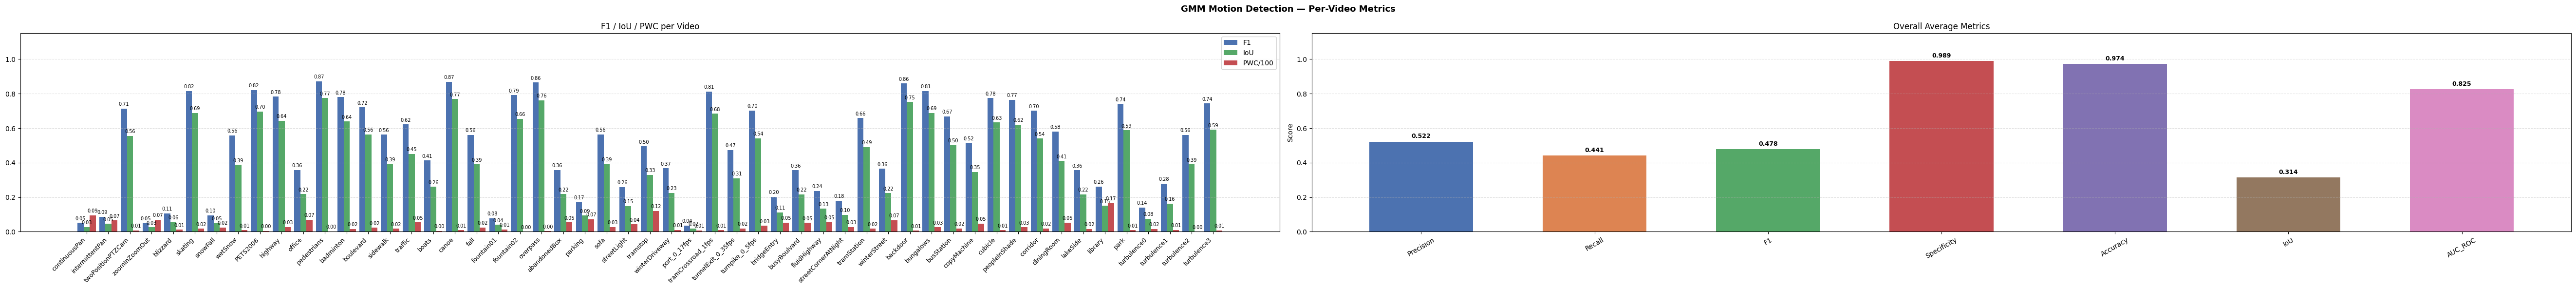

💾 Saved: bar_per_video.png


In [10]:
# ── 9.1 F1 + IoU + PWC theo từng video
n_videos = len(df)
x = np.arange(n_videos)
w = 0.28

fig, axes = plt.subplots(1, 2, figsize=(max(14, n_videos), 6))
fig.suptitle("GMM Motion Detection — Per-Video Metrics", fontsize=13, fontweight="bold")

# Left: F1, IoU, PWC
ax = axes[0]
b1 = ax.bar(x - w,   df["F1"],  w, label="F1",  color="#4C72B0")
b2 = ax.bar(x,       df["IoU"], w, label="IoU", color="#55A868")
b3 = ax.bar(x + w,   df["PWC"]/100, w, label="PWC/100", color="#C44E52")
ax.set_xticks(x); ax.set_xticklabels(df["video_name"], rotation=45, ha="right", fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_title("F1 / IoU / PWC per Video")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f"{h:.2f}", ha="center", va="bottom", fontsize=7)

# Right: Overall average bar
ax2 = axes[1]
metrics_show = ["Precision", "Recall", "F1", "Specificity", "Accuracy", "IoU", "AUC_ROC"]
vals   = [overall_m[m] for m in metrics_show]
colors = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B2","#937860","#DA8BC3"]
bars2  = ax2.bar(metrics_show, vals, color=colors, width=0.6)
ax2.set_ylim(0, 1.15)
ax2.set_title("Overall Average Metrics")
ax2.set_ylabel("Score")
ax2.tick_params(axis="x", rotation=30)
ax2.grid(axis="y", linestyle="--", alpha=0.4)
for bar, val in zip(bars2, vals):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.02,
             f"{val:.3f}", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "bar_per_video.png"), dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved: bar_per_video.png")

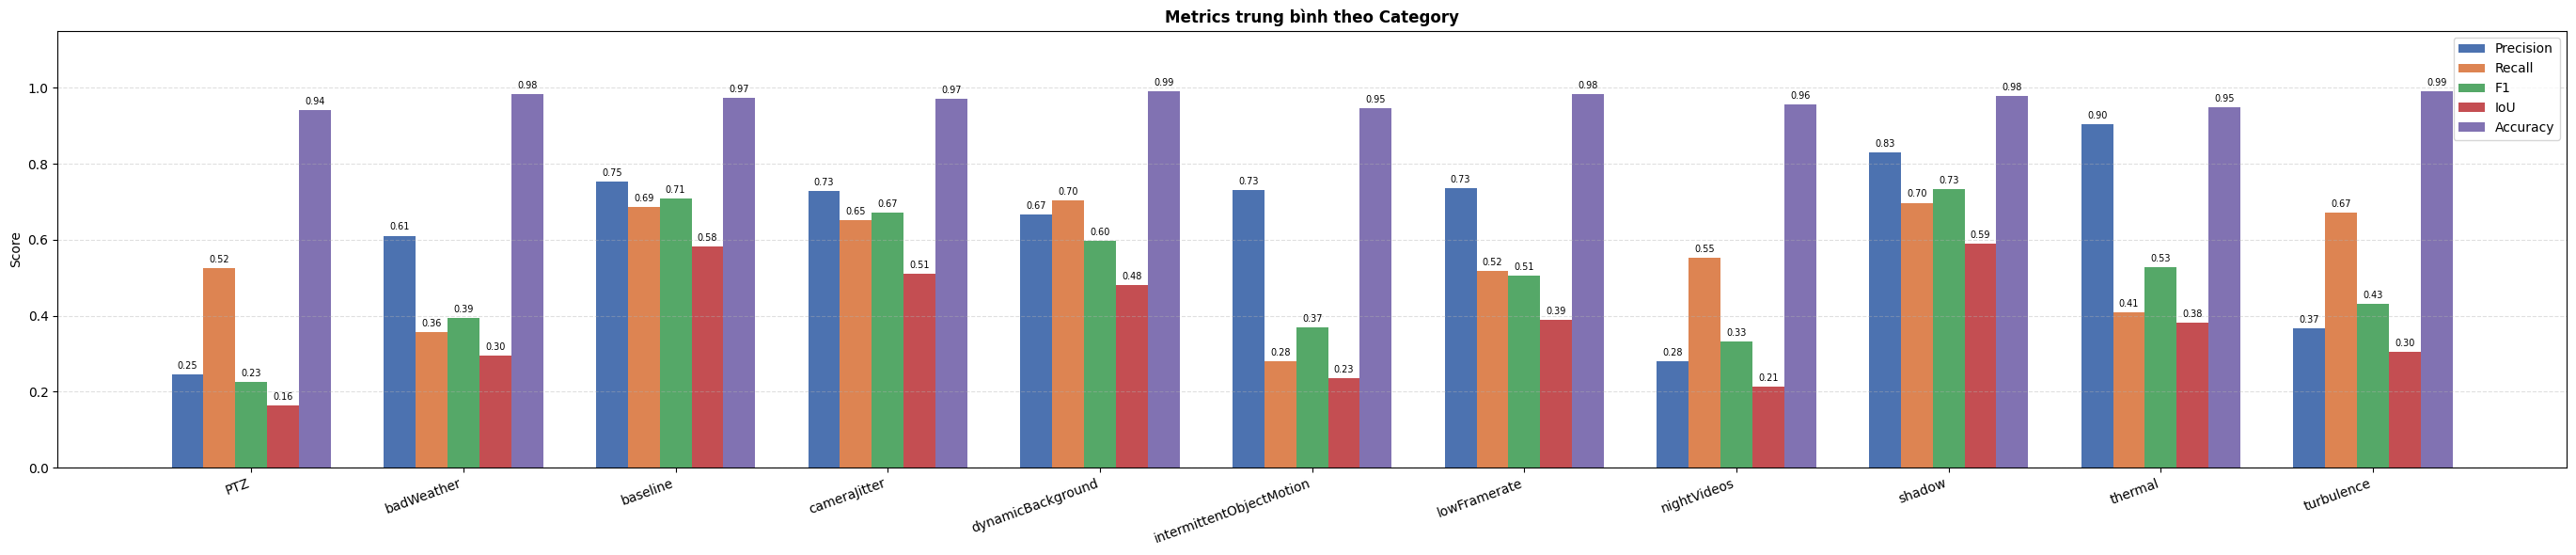

💾 Saved: bar_per_category.png


In [11]:
# ── 9.2 Grouped bar chart theo category
if len(df_cat) >= 1:
    metrics_cat = ["Precision", "Recall", "F1", "IoU", "Accuracy"]
    n_cats  = len(df_cat)
    n_m     = len(metrics_cat)
    x_cat   = np.arange(n_cats)
    w_cat   = 0.15
    offsets = np.linspace(-(n_m-1)/2*w_cat, (n_m-1)/2*w_cat, n_m)
    colors_m = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B2"]

    fig, ax = plt.subplots(figsize=(max(10, n_cats*2.5), 6))
    for i, (metric, color, offset) in enumerate(zip(metrics_cat, colors_m, offsets)):
        vals = df_cat[metric].values
        bars = ax.bar(x_cat + offset, vals, w_cat, label=metric, color=color)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                    f"{v:.2f}", ha="center", va="bottom", fontsize=7)

    ax.set_xticks(x_cat); ax.set_xticklabels(df_cat.index, rotation=20, ha="right")
    ax.set_ylim(0, 1.15)
    ax.set_title("Metrics trung bình theo Category", fontsize=12, fontweight="bold")
    ax.set_ylabel("Score"); ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "bar_per_category.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Saved: bar_per_category.png")

## 10. Radar Chart — So sánh Category

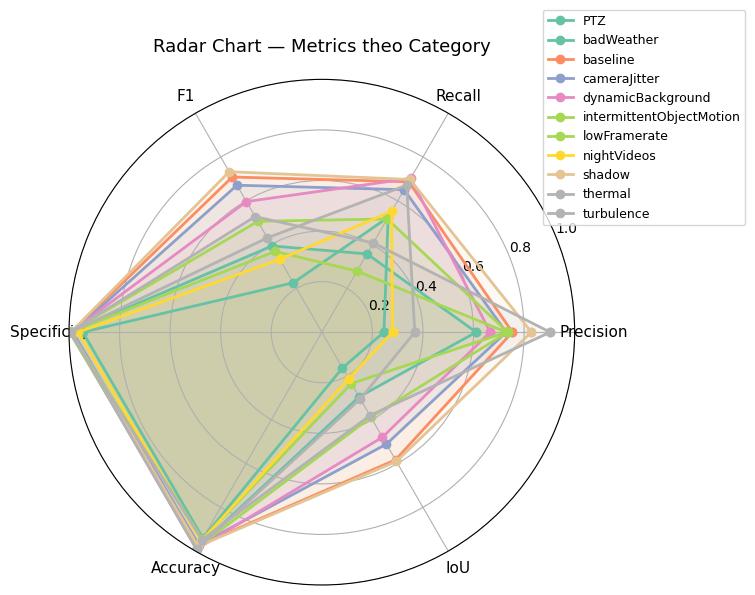

💾 Saved: radar_chart.png


In [12]:
if len(df_cat) >= 2:
    metrics_radar = ["Precision", "Recall", "F1", "Specificity", "Accuracy", "IoU"]
    categories    = df_cat.index.tolist()
    N      = len(metrics_radar)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    colors_r = plt.cm.Set2(np.linspace(0, 1, len(categories)))

    for cat, color in zip(categories, colors_r):
        vals = df_cat.loc[cat, metrics_radar].tolist() + [df_cat.loc[cat, metrics_radar[0]]]
        ax.plot(angles, vals, "o-", linewidth=2, label=cat, color=color)
        ax.fill(angles, vals, alpha=0.1, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics_radar, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_title("Radar Chart — Metrics theo Category", fontsize=13, pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "radar_chart.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Saved: radar_chart.png")
else:
    print("ℹ️ Cần ít nhất 2 category để vẽ radar chart")

## 11. Qualitative — Sample Frames
Hiển thị: **Frame gốc | GMM Mask | Ground Truth | Overlay (TP=xanh, FP=đỏ, FN=vàng)**

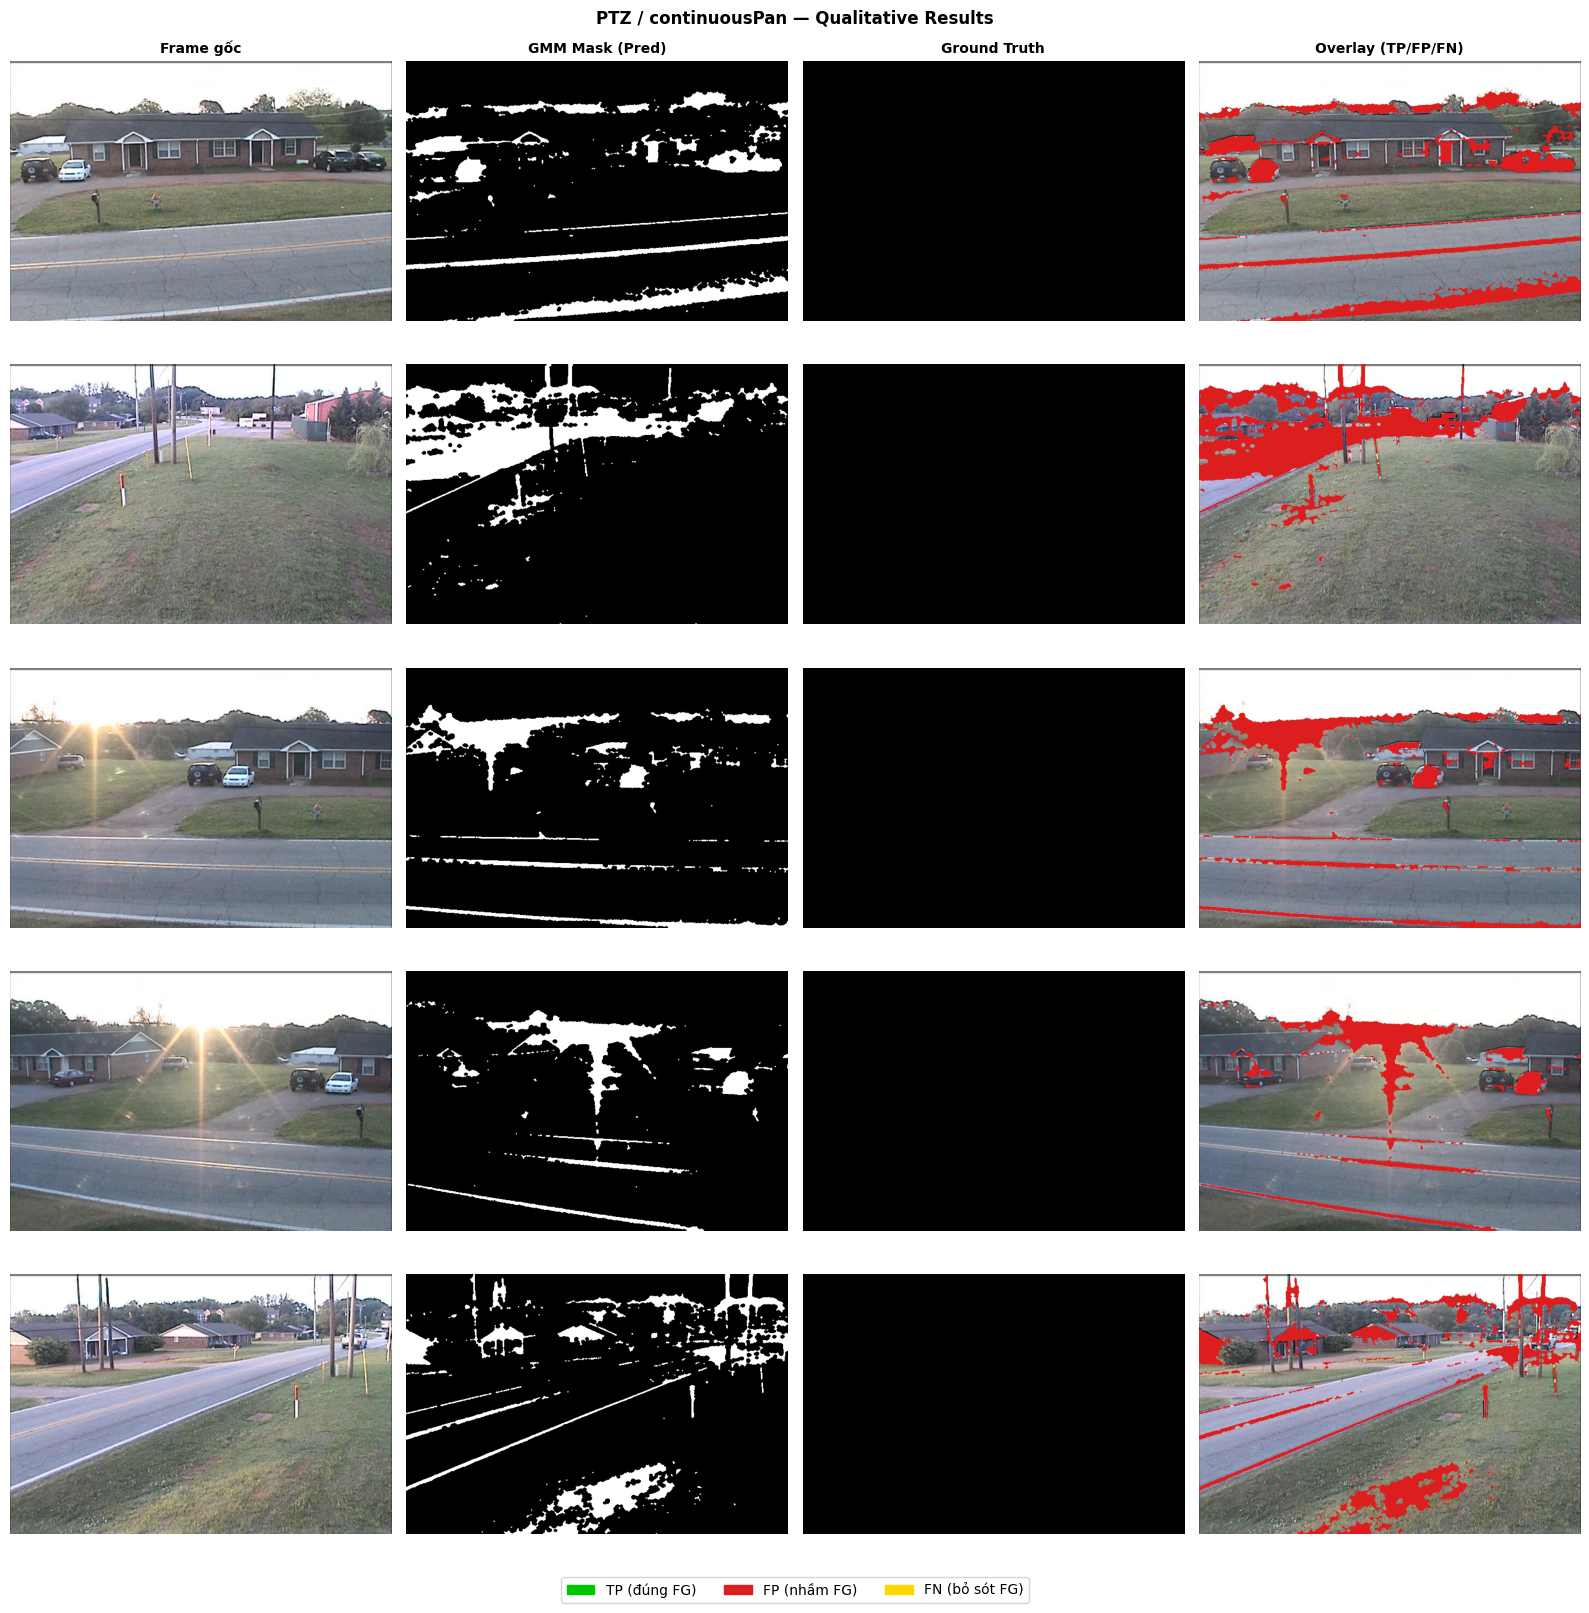

💾 Saved: /kaggle/working/results/sample_continuousPan.png


In [13]:
def visualize_sample_frames(video_info, config, n_samples=5):
    """
    Visualize 4 cột: Frame gốc | GMM Pred | Ground Truth | Overlay (TP/FP/FN).
    Overlay màu:
      Xanh lá  = TP (đúng foreground)
      Đỏ       = FP (báo nhầm foreground)
      Vàng     = FN (bỏ sót foreground)
    """
    input_frames = get_sorted_frames(video_info["input_dir"])
    roi_mask     = None
    if video_info["roi_path"]:
        roi_mask = cv2.imread(video_info["roi_path"], cv2.IMREAD_GRAYSCALE)

    gt_frames = get_sorted_frames(video_info["gt_dir"])
    gt_dict   = {}
    for gp in gt_frames:
        num = "".join(filter(str.isdigit, os.path.basename(gp)))
        gt_dict[num] = gp

    subtractor = cv2.createBackgroundSubtractorMOG2(
        history=config["gmm_history"],
        varThreshold=config["gmm_var_threshold"],
        detectShadows=config["gmm_detect_shadow"])

    warmup = config["warmup_frames"]
    # Warm-up
    for i in range(min(warmup, len(input_frames))):
        f = cv2.imread(input_frames[i])
        if f is not None:
            subtractor.apply(f)

    # Chọn sample indices (sau warm-up)
    start   = warmup
    indices = np.linspace(start, len(input_frames)-1, n_samples, dtype=int)

    fig, axes = plt.subplots(n_samples, 4, figsize=(16, 3.2*n_samples))
    if n_samples == 1:
        axes = [axes]
    fig.suptitle(
        f"{video_info['category']} / {video_info['video_name']} — Qualitative Results",
        fontsize=12, fontweight="bold")

    col_titles = ["Frame gốc", "GMM Mask (Pred)", "Ground Truth", "Overlay (TP/FP/FN)"]
    for j, t in enumerate(col_titles):
        axes[0][j].set_title(t, fontsize=10, fontweight="bold")

    prev_idx = start
    for row, idx in enumerate(indices):
        # Chạy GMM từ prev_idx đến idx để tiếp tục model
        for i in range(prev_idx, idx):
            f = cv2.imread(input_frames[i])
            if f is not None:
                subtractor.apply(f)

        frame = cv2.imread(input_frames[idx])
        if frame is None:
            prev_idx = idx
            continue

        fg_raw   = subtractor.apply(frame)
        _, fg_b  = cv2.threshold(fg_raw, config["binary_threshold"], 255, cv2.THRESH_BINARY)
        fg_clean = postprocess_mask(fg_b, config["morph_open_size"], config["morph_close_size"])

        num    = "".join(filter(str.isdigit, os.path.basename(input_frames[idx])))
        gt_img = cv2.imread(gt_dict[num], cv2.IMREAD_GRAYSCALE) if num in gt_dict else None

        # Overlay với màu TP/FP/FN
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        overlay   = frame_rgb.copy()
        if gt_img is not None:
            pred_fg = fg_clean > 0
            gt_fg   = gt_img == 255
            overlay[pred_fg &  gt_fg] = [0,   200,  0]   # TP = xanh
            overlay[pred_fg & ~gt_fg] = [220,  30, 30]   # FP = đỏ
            overlay[~pred_fg & gt_fg] = [255, 215,  0]   # FN = vàng

        axes[row][0].imshow(frame_rgb)
        axes[row][0].set_ylabel(f"Frame #{idx}", fontsize=8, rotation=0, labelpad=45)

        axes[row][1].imshow(fg_clean, cmap="gray")

        if gt_img is not None:
            gt_display           = np.zeros_like(gt_img)
            gt_display[gt_img == 255] = 255
            axes[row][2].imshow(gt_display, cmap="gray")
        axes[row][2].imshow(gt_display if gt_img is not None else np.zeros((10,10)), cmap="gray")

        axes[row][3].imshow(overlay)

        for ax in axes[row]:
            ax.axis("off")

        prev_idx = idx

    # Legend
    legend_elements = [
        mpatches.Patch(color=[0, 200/255, 0],    label="TP (đúng FG)"),
        mpatches.Patch(color=[220/255, 30/255, 30/255], label="FP (nhầm FG)"),
        mpatches.Patch(color=[255/255, 215/255, 0], label="FN (bỏ sót FG)"),
    ]
    fig.legend(handles=legend_elements, loc="lower center", ncol=3,
               fontsize=10, bbox_to_anchor=(0.5, -0.02))

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f"sample_{video_info['video_name']}.png")
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"💾 Saved: {save_path}")


# Visualize video đầu tiên (có thể thay bằng video bất kỳ)
if video_list:
    visualize_sample_frames(video_list[0], config, n_samples=5)
else:
    print("⚠️ Không có video để visualize")

## 12. Tóm Tắt Kết Quả Cuối Cùng

In [14]:
print("=" * 70)
print("               📊 TÓM TẮT KẾT QUẢ CUỐI CÙNG")
print("=" * 70)
print(f"  Dataset   : CDnet2014")
print(f"  Method    : GMM Background Subtraction (MOG2 — OpenCV)")
print(f"  Videos    : {len(all_results)}")
print()
print(f"  ── Hyperparameters ──────────────────────────────────────")
print(f"  GMM History       : {GMM_HISTORY} frames")
print(f"  varThreshold      : {GMM_VAR_THRESHOLD}")
print(f"  Detect Shadows    : {GMM_DETECT_SHADOW}")
print(f"  Warm-up           : {WARMUP_FRAMES} frames")
print(f"  Binary Threshold  : {BINARY_THRESHOLD}")
print(f"  Morph Open/Close  : {MORPH_OPEN_SIZE} / {MORPH_CLOSE_SIZE}")
print()
print(f"  ── Overall Metrics (aggregate pixel-level) ──────────────")
metric_info = [
    ("Precision",   "TP / (TP+FP)"),
    ("Recall",      "TP / (TP+FN) = TPR"),
    ("F1",          "2·P·R / (P+R)"),
    ("Specificity", "TN / (TN+FP)"),
    ("FPR",         "FP / (FP+TN)  ← nhỏ hơn tốt hơn"),
    ("Accuracy",    "(TP+TN) / Total"),
    ("PWC",         "100·(FN+FP)/Total  ← nhỏ hơn tốt hơn (CDnet2014)"),
    ("IoU",         "TP / (TP+FP+FN)  = Jaccard"),
    ("AUC_ROC",     "Area under ROC curve"),
    ("AUC_PR",      "Area under PR curve"),
]
for key, formula in metric_info:
    val = overall_m[key]
    unit = "%" if key == "PWC" else ""
    print(f"  {key:<12}: {val:>8.4f}{unit}   ({formula})")

print()
print(f"  ── Pixel Counts (aggregate) ─────────────────────────────")
print(f"  TP : {total_TP:>15,}")
print(f"  FP : {total_FP:>15,}")
print(f"  FN : {total_FN:>15,}")
print(f"  TN : {total_TN:>15,}")
print()
print(f"  ── Output Files ─────────────────────────────────────────")
files = [
    "results_per_video.csv",
    "results_per_category.csv",
    "overall_results.json",
    "confusion_matrix_overall.png",
    "confusion_matrix_per_category.png",
    "pr_roc_curves.png",
    "bar_per_video.png",
    "bar_per_category.png",
    "radar_chart.png",
    "sample_<video_name>.png",
]
for f in files:
    print(f"  ├── {f}")
print(f"  └── pred_masks/<category>/<video>/")
print("=" * 70)

               📊 TÓM TẮT KẾT QUẢ CUỐI CÙNG
  Dataset   : CDnet2014
  Method    : GMM Background Subtraction (MOG2 — OpenCV)
  Videos    : 53

  ── Hyperparameters ──────────────────────────────────────
  GMM History       : 500 frames
  varThreshold      : 16
  Detect Shadows    : True
  Warm-up           : 200 frames
  Binary Threshold  : 200
  Morph Open/Close  : 3 / 7

  ── Overall Metrics (aggregate pixel-level) ──────────────
  Precision   :   0.5222   (TP / (TP+FP))
  Recall      :   0.4408   (TP / (TP+FN) = TPR)
  F1          :   0.4781   (2·P·R / (P+R))
  Specificity :   0.9888   (TN / (TN+FP))
  FPR         :   0.0112   (FP / (FP+TN)  ← nhỏ hơn tốt hơn)
  Accuracy    :   0.9740   ((TP+TN) / Total)
  PWC         :   2.6034%   (100·(FN+FP)/Total  ← nhỏ hơn tốt hơn (CDnet2014))
  IoU         :   0.3141   (TP / (TP+FP+FN)  = Jaccard)
  AUC_ROC     :   0.8249   (Area under ROC curve)
  AUC_PR      :   0.1488   (Area under PR curve)

  ── Pixel Counts (aggregate) ───────────────────